<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/For_Loops_How_To_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# Iteration, State Evolution, and Metropolis Sampling

Iteration provides a common mathematical structure for several forms of numerical computation. A deterministic loop advances according to a prescribed sequence of states, whereas a stochastic loop permits a probability law to select the next state. The examples in this computation develop that connection progressively, beginning with Python index traversal, extending to indexed transformations of data, and ending with a Markov chain whose empirical distribution approximates a prescribed probability density.

The final example implements a random walk Metropolis sampler, which is the symmetric proposal case of the more general Metropolis Hastings construction introduced by Metropolis *et al.* (1953) and generalized by Hastings (1970). This approach treats each pass as a transition from the current mathematical state $X_n$ to the subsequent state $X_{n+1}$, moving beyond the simple repetition of instructions. Such an interpretation connects ordinary programming iteration with stochastic state evolution, probability distributions, and numerical integration.

## Core Notation

| Symbol or term | Meaning |
| --- | --- |
| **MCMC** | Markov Chain Monte Carlo |
| $N$ | Number of iterations or sampled states used in the calculation |
| $i,k$ | Integer indices associated with finite sequences |
| $x_k$ | Input value associated with index $k$ |
| $y_k$ | Deterministically transformed value associated with $x_k$ |
| $X_n$ | State of the Markov chain after iteration $n$ |
| $X'$ | Candidate state proposed from the current state |
| $\pi(x)$ | Target probability density |
| $q(X'\mid X_n)$ | Proposal density for generating $X'$ from $X_n$ |
| $\epsilon_n$ | Random displacement applied to the current state |
| $\sigma_q$ | Standard deviation controlling the proposal displacement |
| $\alpha(X_n,X')$ | Metropolis Hastings acceptance probability |
| $U_n$ | Uniform random variate used in the acceptance decision |
| $f(x)$ | Integrable function evaluated over the sampled state space |
| $\Delta x_j$ | Width of histogram bin $j$ |
| $n_j$ | Number of sampled states contained in bin $j$ |
| $\widehat{\pi}_j$ | Histogram estimate of the probability density in bin $j$ |

## Deterministic Iteration as State Evolution

The first `for` loop advances an integer index across a finite ordered set,

$$i\in\{0,1,\ldots,N-1\}.$$

Each pass corresponds to one discrete computational step. Its progression can be interpreted as the deterministic state transition

$$i\mapsto i+1.$$

A second example associates numerical data with this indexing process. Given an input sequence $x_k$, the transformed sequence satisfies

$$y_k=2.5x_k.$$

Using `enumerate(zip(...))` exposes the indexed data state

$$(k,x_k,y_k).$$

Here, $k$ identifies position within the sequence, $x_k$ supplies the corresponding input value, and $y_k$ records its deterministic transformation. Iteration consequently acquires a mathematical interpretation beyond repeated program execution. Each pass represents movement from one state of a discrete process to another according to a specified transition rule.

Stochastic computation extends the same idea by replacing a predetermined update with a transition governed by probability. The loop still advances step by step, although its trajectory is now generated from random variables and conditional distributions.

## Markov State Evolution

The MCMC portion of the script evolves a real valued state $X_n\in\mathbb{R}$. Its transition law satisfies the Markov property. For every measurable set $A$,

$$P\left(X_{n+1}\in A\mid X_n,X_{n-1},\ldots,X_0\right)=P\left(X_{n+1}\in A\mid X_n\right).$$

Conditional distributions of the next state are determined from the present state. Earlier states can still influence future motion indirectly, as their cumulative history is encoded in the current value $X_n$.

Target distributions used in the script follow the standard normal density,

$$\pi(x)=\frac{1}{\sqrt{2\pi}}\exp\left(-\frac{x^2}{2}\right).$$

MCMC constructs a dependent sequence of states whose long run statistical behavior is governed by this density. The algorithm accomplishes that objective by combining a candidate generating mechanism with a probabilistic acceptance rule.

## Gaussian Random Walk Proposal

At iteration $n$, the algorithm generates a candidate state according to

$$X'=X_n+\epsilon_n,\qquad \epsilon_n\sim\mathcal{N}(0,\sigma_q^2).$$

The parameter $\sigma_q$, represented in the script by `MCMC_PROPOSAL_WIDTH`, determines the characteristic length scale of each proposed displacement. Conditional on the current state,

$$X'\mid X_n\sim\mathcal{N}(X_n,\sigma_q^2).$$

The corresponding proposal density is

$$q(X'\mid X_n)=\frac{1}{\sqrt{2\pi\sigma_q^2}}\exp\left[-\frac{(X'-X_n)^2}{2\sigma_q^2}\right].$$

A zero centered Gaussian increment assigns equal density to opposite displacements of identical magnitude. Consequently,

$$q(X'\mid X_n)=q(X_n\mid X').$$

This symmetry reduces the general Metropolis Hastings rule to the original Metropolis acceptance law. Chib and Greenberg (1995) describe precisely this random walk construction in the form $y=x+z$, with a symmetric increment distribution producing the corresponding density ratio acceptance rule.

## Metropolis Hastings Acceptance Probability

For a general candidate generating density, the Metropolis Hastings acceptance probability is

$$\alpha(X_n,X')=\min\left\{1,\frac{\pi(X')q(X_n\mid X')}{\pi(X_n)q(X'\mid X_n)}\right\}.$$

Symmetry of the Gaussian proposal gives

$$q(X'\mid X_n)=q(X_n\mid X'),$$

so the proposal terms cancel and leave

$$\alpha(X_n,X')=\min\left\{1,\frac{\pi(X')}{\pi(X_n)}\right\}.$$

Only the relative target density at the candidate and current states enters this expression. Any multiplicative normalization constant shared by the numerator and denominator cancels, which permits Metropolis Hastings sampling from distributions whose densities are available only up to proportionality.

Regarding the standard normal target,

$$\frac{\pi(X')}{\pi(X_n)}=\exp\left[-\frac{X'^2-X_n^2}{2}\right].$$

The corresponding acceptance probability is

$$\alpha(X_n,X')=\min\left\{1,\exp\left[-\frac{X'^2-X_n^2}{2}\right]\right\}.$$

Next, the script generates an independent uniform random variate,

$$U_n\sim\mathcal{U}(0,1).$$

Comparison of $U_n$ with the acceptance probability determines the next chain state,

$$X_{n+1}=\begin{cases}X',&U_n<\alpha(X_n,X'),\\X_n,&U_n\geq\alpha(X_n,X').\end{cases}$$

If the candidate lies at a point of greater target density, then $\pi(X')\geq\pi(X_n)$ and the acceptance probability equals unity. Proposals directed toward regions of lower density retain a positive probability of acceptance determined by the density ratio. Such transitions allow the chain to explore the distribution, avoiding the convergence toward a single density maximum characteristic of optimization algorithms.

## Why Rejection Produces a Repeated State

A rejected candidate gives the update

$$X_{n+1}=X_n.$$

The repeated value forms part of the Markov chain and carries statistical meaning. Retaining the current state assigns the correct probability to staying at that location under the transition kernel, which is an explicit component of the Metropolis Hastings construction described by Chib and Greenberg (1995).

Deleting rejected states from the trajectory would change the relative frequency with which regions of the state space are represented. Each completed transition consequently contributes one state to the stored chain, regardless of whether the proposed displacement produces motion.

## Invariant Density and Long Run Sampling

The Metropolis Hastings transition is constructed so that $\pi$ is an invariant density of the chain. Invariance means that a state distributed according to $\pi$ retains that same distribution after application of the transition kernel.

Let $P(x,dy)$ denote the Markov transition kernel. Invariance can be expressed as

$$\pi(y)\,dy=\int_{\mathbb{R}}P(x,dy)\pi(x)\,dx.$$

A common route to this property is detailed balance,

$$\pi(x)P(x,dy)=\pi(y)P(y,dx).$$

The acceptance probability compensates for asymmetry between proposed forward and reverse transitions so that the target density is preserved. For the symmetric random walk used here, the correction reduces to the target density ratio already derived above.

Sampled trajectories can then be used to estimate expectations. For an integrable quantity $f$ and an ergodic chain,

$$\frac{1}{N}\sum_{n=1}^{N}f(X_n)\xrightarrow[N\to\infty]{\mathrm{a.s.}}\mathbb{E}_{\pi}[f(X)].$$

The expectation on the right hand side is

$$\mathbb{E}_{\pi}[f(X)]=\int_{-\infty}^{\infty}f(x)\pi(x)\,dx.$$

This relationship connects iterative sampling with numerical integration. MCMC designs a local transition mechanism whose long run trajectory supplies weighted information about that density, bypassing the need to construct independent samples directly from a complicated density.

Finite trajectories retain serial correlation and may preserve some influence from their initial state during an early transient period. Chib and Greenberg (1995) discuss irreducibility, aperiodicity, transient behavior, and serial correlation as central considerations for interpreting an MCMC sample.

## Empirical Density from the Markov Chain

The histogram produced at the end of the script converts the sampled trajectory into an empirical density estimate. Suppose histogram bin $j$ has width $\Delta x_j$ and contains $n_j$ of the $N$ stored states. Its estimated density is

$$\widehat{\pi}_j=\frac{n_j}{N\Delta x_j}.$$

The resulting histogram approximately satisfies the normalization condition

$$\sum_j\widehat{\pi}_j\Delta x_j\approx1.$$

For this calculation, increasing the number of representative samples should cause the normalized histogram to reproduce the bell shaped profile associated with $\mathcal{N}(0,1)$. Finite sampling produces statistical fluctuations, so agreement is expected at the level of distributional structure instead of exact agreement at every histogram bin.

This histogram also exposes the conceptual progression developed by the program. An ordinary loop generates an ordered sequence of computational states, whereas the Metropolis loop generates a correlated trajectory whose accumulated occupation frequencies approximate a probability distribution.

## Proposal Width and Sampling Efficiency

The proposal width $\sigma_q$ controls the characteristic displacement attempted during each iteration. Small values generate candidate states close to $X_n$, which commonly yields frequent acceptance together with strong correlation between neighboring samples. Large values permit longer excursions across the state space, although proposals reaching regions of low target density acquire smaller acceptance probabilities.

Sampling efficiency consequently reflects a tradeoff between local acceptance and effective exploration. Chib and Greenberg (1995) discuss this relationship in terms of proposal spread, acceptance rate, sample space coverage, and serial correlation. They also caution that a favorable acceptance rate alone does not guarantee an efficient chain.

The value $\sigma_q=1$ gives the proposal increment the same standard deviation as the one dimensional target distribution in this demonstration. Its purpose here is pedagogical, providing a transparent scale at which accepted motion, rejected motion, serial dependence, and distributional exploration can all be observed within the same computation.

## Computational Progression

```text
Python iteration
│
├── Deterministic index evolution
│   └── i → i + 1
│
├── Indexed data transformation
│   ├── input x_k
│   ├── transformation y_k = 2.5 x_k
│   └── indexed state (k, x_k, y_k)
│
└── Stochastic state evolution
    ├── current state X_n
    ├── Gaussian candidate X'
    ├── proposal density q(X' | X_n)
    ├── target density ratio
    ├── acceptance probability α(X_n, X')
    └── next state X_{n+1}
        │
        └── accumulated Markov chain
            ├── correlated samples
            ├── sample averages
            │   └── expectation under π
            └── normalized histogram
                └── empirical approximation of π(x)

```

## References

1. Metropolis, N., Rosenbluth, A.W., Rosenbluth, M.N., Teller, A.H. and Teller, E. (1953) ‘Equation of state calculations by fast computing machines’, *The Journal of Chemical Physics*, 21(6), pp. 1087–1092. https://doi.org/10.1063/1.1699114
2. Hastings, W.K. (1970) ‘Monte Carlo sampling methods using Markov chains and their applications’, *Biometrika*, 57(1), pp. 97–109. https://doi.org/10.1093/biomet/57.1.97
3. Tierney, L. (1994) ‘Markov chains for exploring posterior distributions’, *The Annals of Statistics*, 22(4), pp. 1701–1762. https://doi.org/10.1214/aos/1176325750
4. Chib, S. and Greenberg, E. (1995) ‘Understanding the Metropolis-Hastings algorithm’, *The American Statistician*, 49(4), pp. 327–335. https://doi.org/10.1080/00031305.1995.10476177
5. Andrieu, C., de Freitas, N., Doucet, A. and Jordan, M.I. (2003) ‘An introduction to MCMC for machine learning’, *Machine Learning*, 50(1–2), pp. 5–43. https://doi.org/10.1023/A:1020281327116

In [1]:
!uv pip install numpy cupy-cuda12x matplotlib

Using Python 3.13.15 environment at: /usr
Checked 3 packages in 226ms


Commencing basic loop demonstration.
Current iteration index is 0.
Current iteration index is 1.
Current iteration index is 2.
Current iteration index is 3.
Current iteration index is 4.

Commencing advanced loop demonstration.
Index 0 contains the primary element 1.5 alongside the derived element 3.75.
Index 1 contains the primary element 3.0 alongside the derived element 7.5.
Index 2 contains the primary element 4.5 alongside the derived element 11.25.
Index 3 contains the primary element 6.0 alongside the derived element 15.0.

Commencing Metropolis sampling simulation.


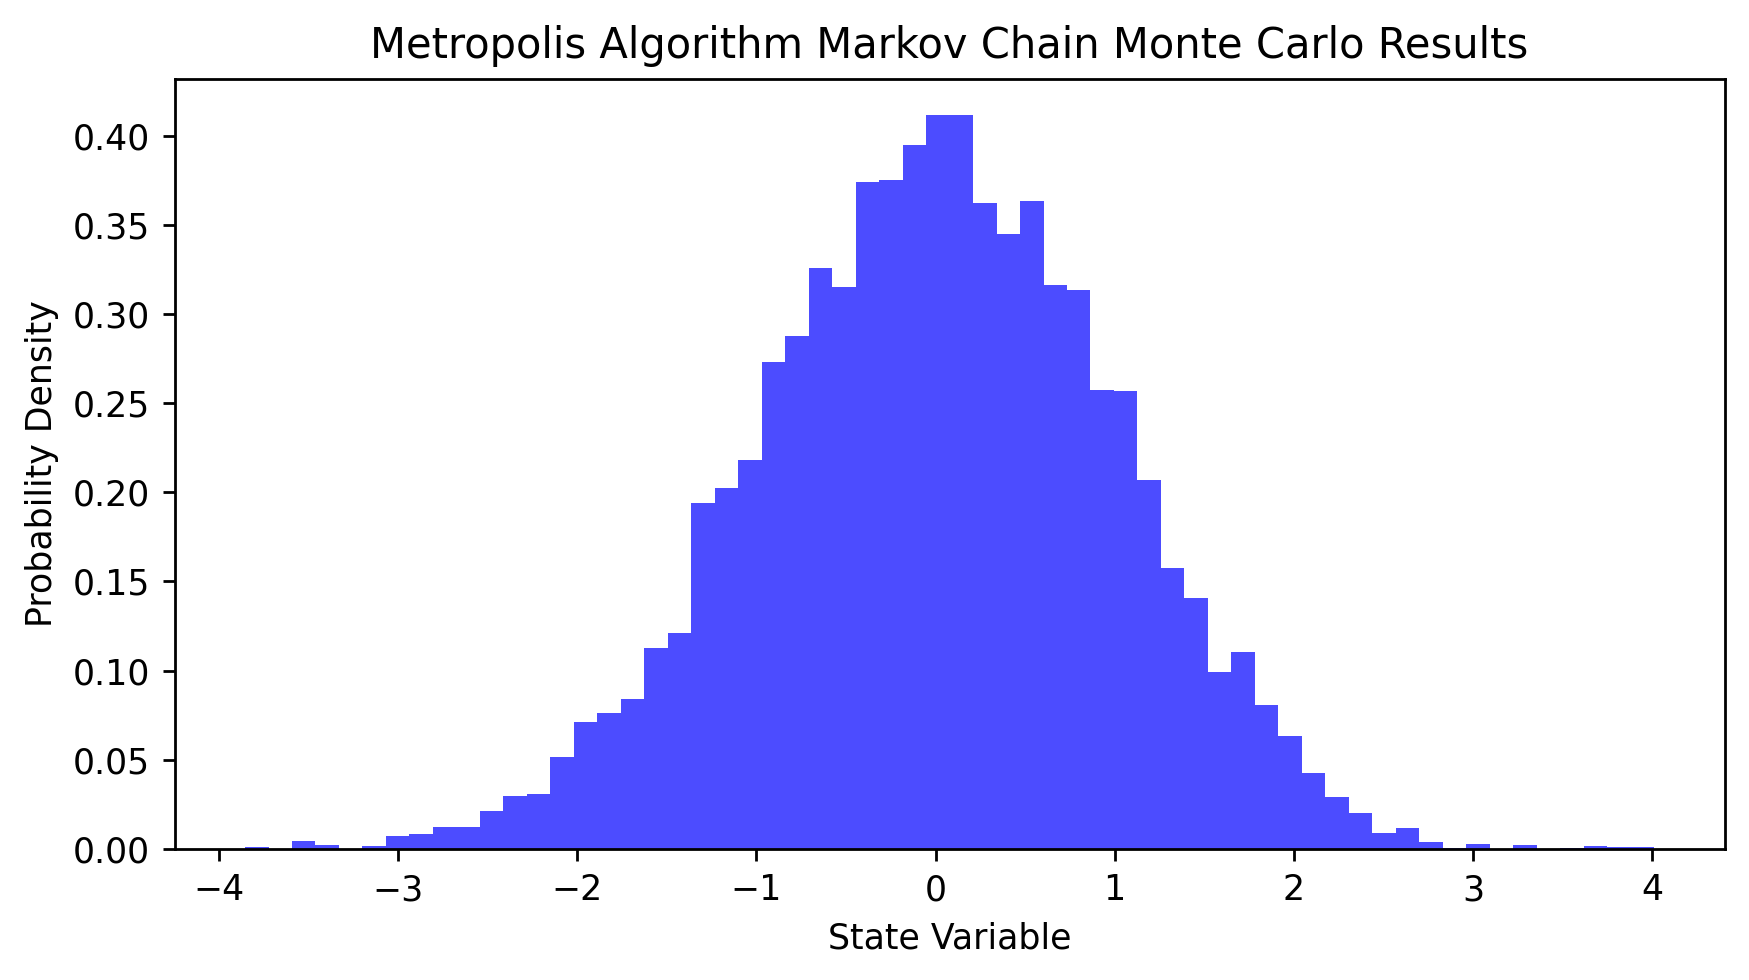

In [3]:
"""This script demonstrates foundational and advanced iterative structures in Python, culminating in a Metropolis sampling simulation designed for execution within Google Colab."""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ---------------------------------------------------
# Control Knobs
# ---------------------------------------------------
NUM_BASIC_ITERATIONS = 5
MCMC_TOTAL_SAMPLES = 15000
MCMC_PROPOSAL_WIDTH = 1.0
MCMC_STARTING_VALUE = 0.0

rcParams['figure.dpi'] = 250
rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
rcParams['font.weight'] = 'normal'

# ---------------------------------------------------
def execute_basic_loop(iterations: int) -> None:
    """This function introduces the elementary 'for' loop mechanics in Python.

    Iterative traversal over a sequence represents a core paradigm in programmatic logic.
    The basic loop iterates sequentially through an iterable object (such as a generated range,
    populated list, or static tuple), assigning the current element to a target variable
    during each successive pass. This mechanism allows operations to be applied uniformly
    across data structures without requiring manual repetition of the underlying code blocks.
    The built-in 'range' function frequently accompanies these loops to generate uniform
    integer sequences efficiently, which provides a predictable and controlled execution envelope.

    Args:
        iterations: An integer defining the total number of cycles the loop will execute.
    """
    print("Commencing basic loop demonstration.")
    for i in range(iterations):
        print(f"Current iteration index is {i}.")

# ---------------------------------------------------
def execute_advanced_loop(data_sequence: list) -> None:
    """This function demonstrates advanced iteration techniques utilizing 'enumerate' and 'zip'.

    While basic loops handle solitary sequences adequately, complex data processing often necessitates
    concurrent traversal of multiple arrays or the simultaneous tracking of an element along with
    its positional index. The 'enumerate' function yields both the numerical index and the
    corresponding value from the iterable, whereas the 'zip' function synchronizes multiple
    iterables into unified tuples. Employing these native utilities minimizes the need for
    auxiliary counter variables, which ultimately reduces potential indexing errors and
    enhances overall script readability during rigorous data science applications.

    Args:
        data_sequence: A list containing generic float elements to be processed.
    """
    print("\nCommencing advanced loop demonstration.")
    secondary_sequence = [val * 2.5 for val in data_sequence]

    for index, (primary_value, secondary_value) in enumerate(zip(data_sequence, secondary_sequence)):
         print(f"Index {index} contains the primary element {primary_value} alongside the derived element {secondary_value}.")

# ---------------------------------------------------
def execute_metropolis_simulation(num_samples: int, step_size: float, initial_state: float) -> np.ndarray:
    """This function executes a Metropolis sampling simulation utilizing an iterative loop structure.

    The Metropolis algorithm constitutes a foundational Markov Chain Monte Carlo (MCMC) method,
    which is utilized to generate representative samples from a complex Probability Density Function (PDF).
    The procedure initializes at a designated starting coordinate and proposes random subsequent states
    based on a predefined step size. The algorithm evaluates the relative probability of the proposed
    state against the current state, accepting advantageous transitions unconditionally while accepting
    disadvantageous transitions with a probability proportional to the density ratio. This stochastic
    acceptance criterion guarantees that the sequence of generated samples eventually converges to the
    target distribution over time. The 'for' loop manages this sequential state evolution by continuously
    evaluating transitions and conditionally appending accepted proposals to a persistent chain array.

    Args:
        num_samples: An integer specifying the total number of probabilistic samples to generate.
        step_size: A float dictating the standard deviation of the Gaussian proposal distribution.
        initial_state: A float establishing the starting coordinate for the Markov chain.

    Returns:
        An array containing the accepted continuous state variables drawn from the target distribution.
    """
    print("\nCommencing Metropolis sampling simulation.")
    samples = np.zeros(num_samples)
    current_state = initial_state
    samples[0] = current_state

    def evaluate_target_pdf(x: float) -> float:
        """Evaluates an arbitrary target Gaussian distribution centered at zero."""
        return np.exp(-0.5 * x**2) / np.sqrt(2.0 * np.pi)

    for i in range(1, num_samples):
        proposed_state = current_state + np.random.normal(0.0, step_size)
        acceptance_ratio = evaluate_target_pdf(proposed_state) / evaluate_target_pdf(current_state)

        if np.random.uniform(0.0, 1.0) < acceptance_ratio:
            current_state = proposed_state

        samples[i] = current_state

    return samples

# ---------------------------------------------------
def main() -> None:
    """Main execution sequence integrating the three demonstration phases."""
    execute_basic_loop(NUM_BASIC_ITERATIONS)

    sample_data = [1.5, 3.0, 4.5, 6.0]
    execute_advanced_loop(sample_data)

    mcmc_results = execute_metropolis_simulation(MCMC_TOTAL_SAMPLES, MCMC_PROPOSAL_WIDTH, MCMC_STARTING_VALUE)

    plt.figure(figsize=(8, 4))
    plt.hist(mcmc_results, bins=60, density=True, alpha=0.7, color='blue')
    plt.title('Metropolis Algorithm Markov Chain Monte Carlo Results')
    plt.xlabel('State Variable')
    plt.ylabel('Probability Density')
    plt.show()

if __name__ == '__main__':
    main()